# Estimating Market Impact From Position Accumulation  
**Author:** Grant Reed 

**Date:** February 23, 2026 

---

## Volume-Driven Price Impact in Cryptocurrency Markets 
This study investigates the temporary price impact $I(V)$ of trade volume $V$ for Ethereum (ETH) and Solana (SOL) across global trading venues. 

Our research compares the theoretical **Square Root Law** ($V^{0.5}$) against an empirical **Power Law** fit ($V^{\mu_2}$) to identify the true degree of concavity in crypto-asset liquidity.

In [1]:
import yfinance as yf 
import pandas as pd
import pandas_datareader.data as web
import numpy as np
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from IPython.display import display

import datetime
import itertools 
import os
import seaborn as sns

# Section 1: Data Assembly & Universal Functions 
## 1.1 Data Assembly
We begin by importing the **1/6th subsample of ETH high-frequency trade data.**

In [2]:
eth_raw = pd.read_parquet('ETH-USDT_fewer_trades.parquet', engine = 'fastparquet') # loads data into Pandas DataFrame.

In [3]:
eth_raw['ts'] = pd.to_datetime(eth_raw['ts']) # ensures 'ts' is datetime and sort by date 
eth_raw = eth_raw.sort_values('ts').reset_index(drop=True) # reset index after full sort for clean slicing
eth_raw.head(2) # check first few rows 

,ts,side,qty,trade_price,Exchange
0,2025-05-01 00:00:00.108554640,B,0.040151,1793.41,OKX
1,2025-05-01 00:00:01.487113175,B,0.005700,1793.41,OKX


In [4]:
eth_raw['Exchange'].unique()

array(['OKX', 'COINBASE', 'BITSTAMP', 'GATE_IO'], dtype=object)

The Ethereum (ETH) dataset spans four exchanges: **OKX, Coinbase, Bitstamp, and Gate.io.**  

## 1.2 Universal Functions 

### Data Preprocessing
This function transforms our raw trade data into a structured dataset for impact modeling. 
* **Order Reconstruction:** Rebuilds original market sweeps by aggregating fragemented fills across identical timestamps and venues via Volume-Weighted Average Price (VWAP). 
* **Trade-Count Clock:** Utilizes a discrete event clock ($M$-horizon) rather than wall-clock time to capture price responses.
* **Sign Alignment**: Normalizes price movement into Directional Returns ($r_n$) --> prevents buy and sell reactions from canceling, ensuring a positive impact metric for regression.

In [5]:
def process_data(df, M_horizon=10):
    # Notional Calculation for VWAP
    df = df.copy() # Avoid SettingWithCopy warnings
    df['notional'] = df['trade_price'] * df['qty']

    # Aggregate Split Fills (Rebuilding the original market orders)
    # Observed=False handles the Categorical warning for Exchange/Side
    aggregated = df.groupby(['Exchange', 'side', 'ts'], observed=False).agg(
        qty=('qty', 'sum'),
        notional=('notional', 'sum')
    ).reset_index()

    # Calculate VWAP (P_n) and Cleanup
    aggregated['trade_price'] = aggregated['notional'] / aggregated['qty']
    aggregated = aggregated.drop(columns=['notional'])

    # Chronological Sorting by Venue
    aggregated = aggregated.sort_values(by=['Exchange', 'ts']).reset_index(drop=True)

    # Apply Trade-Count Clock (M steps forward)
    # Grouping by Exchange prevents mixing future prices across venues
    aggregated['P_n_plus_M'] = aggregated.groupby('Exchange', observed=False)['trade_price'].shift(-M_horizon)

    # Drop tails (rows where future price doesn't exist)
    aggregated = aggregated.dropna(subset=['P_n_plus_M']).copy()

    # Directional Return Calculation
    aggregated['direction'] = np.where(aggregated['side'] == 'B', 1, -1)
    aggregated['r_n'] = (
        (aggregated['P_n_plus_M'] / aggregated['trade_price']) - 1
    ) * aggregated['direction']

    return aggregated

### Statistical Cohort Binning 
We use quantile-based cohort binning to isolate the relationship between trade size and price response. 
* **Volume Isolation:** Slices the dataset using quantile thresholds ($K$ to $L$)
* **Variance Reduction**: Aggregates trade data into N equal-sized cohorts, producing stable mean estimates for curve fitting. This ensures that outliers do not bias the estimated model exponents.

In [6]:
def create_cohort_buckets(df_subset, K, L, num_buckets=15):
    # Calculate volume thresholds for the specific cohort
    k_threshold = df_subset['qty'].quantile(K)
    l_threshold = df_subset['qty'].quantile(L)
    
    # Isolate the target zone
    target_zone = df_subset[
        (df_subset['qty'] >= k_threshold) & 
        (df_subset['qty'] < l_threshold)
    ].copy()

    if len(target_zone) < num_buckets:
        return None
        
    # Bin the data
    target_zone['quantile_bin'] = pd.qcut(
        target_zone['qty'], 
        q=num_buckets, 
        labels=False, 
        duplicates='drop')
    
    # Aggregate to get X and Y for fitting
    aggregated_cohorts = target_zone.groupby('quantile_bin').agg(
        V_n_mean=('qty', 'mean'),
        r_n_mean=('r_n', 'mean'),
        trade_count=('qty', 'count')
    ).reset_index(drop=True)
    
    return aggregated_cohorts

### Theoretical Models 
**Model 1: The Square Root Law (Classical Theory)**
* Price impact scales precisely with the square root of trade volume:
  
   $r = \mu_0 \sqrt{V}$
* Serves as the null hypothesis. It assumes a specific, rigid degree of concavity ($\mu_2 = 0.5$).
  
**Model 2: The Generalized Power Law** 
* Actual data estimates both the scaling coefficient ($\mu_1$) and concavity of impact curve ($\mu_2$):
  
   $r = \mu_1 V^{\mu_2}$
  
* By relaxing the 0.5 constraint, we can empirically measure the true liquidity "physics" of the asset.

*  **If $\mu_2 \approx 0.5$, classical theory is upheld.**

In [7]:
# Model 1: Square Root Law 
def model_1(V, mu_0):
    return mu_0 * np.sqrt(V)

# Model 2: Power Law 
def model_2(V, mu_1, mu_2):
    return mu_1 * (V ** mu_2)

### Parameter Estimation & Optimization
Our core analytical function utilizes Non-Linear Least Squares (NLLS) optimization to map empirical trade data to our theoretical frameworks.
* **Regime Focus:** Targets volume boundaries ($K, L$)

In [8]:
def fit_models(aggregated_df, K_val=0.80, L_val=0.9975, n_buckets=15):

    # Extract Cohort Data using our existing function
    cohort_data = create_cohort_buckets(aggregated_df, K=K_val, L=L_val, num_buckets=n_buckets)
    
    X_data = cohort_data['V_n_mean'].values
    Y_data = cohort_data['r_n_mean'].values

    # Data Validation
    valid = (X_data > 0) & ~np.isnan(Y_data)
    X_data, Y_data = X_data[valid], Y_data[valid]
    
    if len(X_data) < 2:
        return {"error": "Insufficient data for fitting"}

    # Fit Model 1: Square Root Law (r = mu_0 * sqrt(V))
    popt_1, _ = curve_fit(model_1, X_data, Y_data, bounds=([0], [np.inf]))
    mu_0_est = popt_1[0]

    # Fit Model 2: Power Law (r = mu_1 * V^mu_2)
    popt_2, _ = curve_fit(model_2, X_data, Y_data, p0=[1e-5, 0.5], 
                          bounds=([0, 0], [np.inf, 1.0]))
    mu_1_est, mu_2_est = popt_2

    # Return results 
    return {
        'X_data': X_data,
        'Y_data': Y_data,
        'mu_0': mu_0_est,
        'mu_1': mu_1_est,
        'mu_2': mu_2_est,
        'K': K_val,
        'L': L_val
    }

# Section 2: Ethereum (ETH) | Empirical Analysis 

In [9]:
eth_aggregated = process_data(eth_raw, M_horizon=10) # process raw ETH data 
eth_results = fit_models(eth_aggregated) # fit our aggregated ETH data into Models 1 & 2 

In [10]:
def plot_impact_results(res, asset_label="Ethereum"):
    # Extract data from the results dictionary
    X_data = res['X_data']
    Y_data = res['Y_data']
    mu_0 = res['mu_0']
    mu_1 = res['mu_1']
    mu_2 = res['mu_2']

    # Generate smooth lines for the fitted models
    X_fit = np.linspace(X_data.min(), X_data.max(), 100)
    Y_fit_1 = model_1(X_fit, mu_0)
    Y_fit_2 = model_2(X_fit, mu_1, mu_2)

    # Create the figure
    plt.figure(figsize=(10, 6))
    plt.scatter(X_data, Y_data, color='black', label=f'Empirical {asset_label}', zorder=5)

    # Model 1 (Square Root) - Dashed Blue
    plt.plot(X_fit, Y_fit_1, 'b--', 
             label=f'Model 1 (Square Root): $\mu_0$={mu_0:.2e}')
    
    # Model 2 (Power Law) - Solid Red
    plt.plot(X_fit, Y_fit_2, 'r-', 
             label=f'Model 2 (Power Law): $\mu_2$={mu_2:.4f}')

    # Formatting
    plt.title(f'Market Impact Estimation ({asset_label}): $K \geq {res["K"]}$ to $L < {res["L"]}$', fontsize=14)
    plt.xlabel('Mean Trade Volume ($V_n$)', fontsize=12)
    plt.ylabel('Mean Directional Return ($r_n$)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()

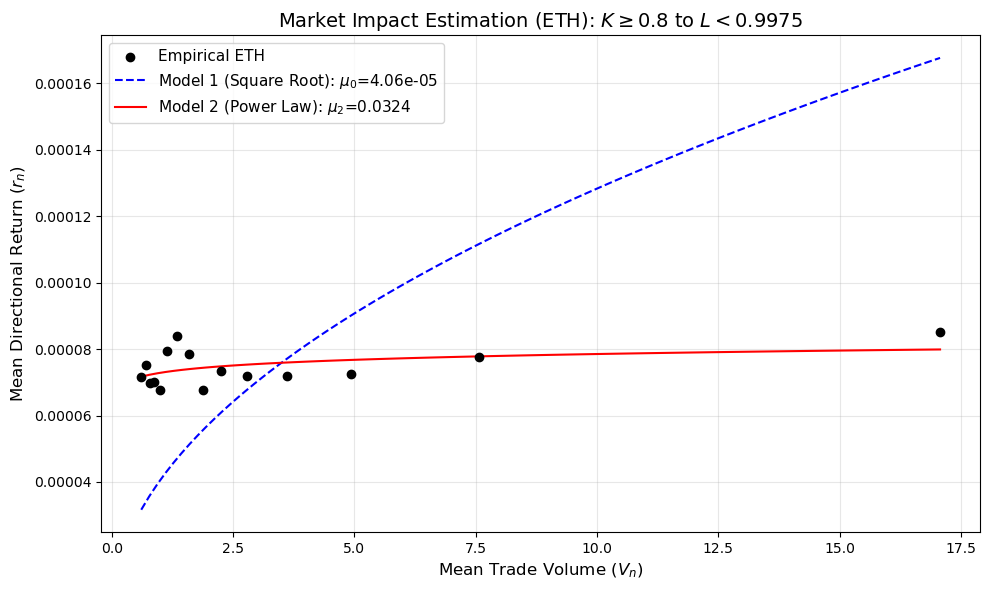

In [11]:
plot_impact_results(eth_results, asset_label="ETH")

In [12]:
print(f"ETH Square Root Law (mu_0): {eth_results['mu_0']:.8f}")
print(f"ETH Power Law Exponent (mu_1): {eth_results['mu_1']:.4f}")
print(f"ETH Power Law Exponent (mu_2): {eth_results['mu_2']:.4f}")

ETH Square Root Law (mu_0): 0.00004057
ETH Power Law Exponent (mu_1): 0.0001
ETH Power Law Exponent (mu_2): 0.0324


## 2.1 Market Impact Estimation 
Empirical directional returns (black dots) are averaged across 15 equal-sized volume cohorts to isolate the underlying impact curve.

**Model 1 (Square Root):** 
* The classical framework **severely overestimates price impact as trade size increases.**
* $\mu_0 = 4.06 \times 10^{-5}$

**Model 2 (Power Law):**
* Ethereum's highly concave market impact is an **extreme deviation from the theoretical benchmark ($\mu_2 = 0.5$).**
* $\mu_1 = 0.0001$ (scaling coefficient)
* $\mu_2 = 0.0324$ (empirical exponent) 

In [13]:
def get_error_metrics(res, asset_label="ETH"):
    X_data = res['X_data']
    Y_data = res['Y_data']
    
    # Generate Predictions
    Y_pred_1 = model_1(X_data, res['mu_0'])
    Y_pred_2 = model_2(X_data, res['mu_1'], res['mu_2'])

    # Calculate MSE
    mse_1 = np.mean((Y_data - Y_pred_1)**2)
    mse_2 = np.mean((Y_data - Y_pred_2)**2)

    # Calculate R-squared
    ss_tot = np.sum((Y_data - np.mean(Y_data))**2)
    r2_1 = 1 - (np.sum((Y_data - Y_pred_1)**2) / ss_tot)
    r2_2 = 1 - (np.sum((Y_data - Y_pred_2)**2) / ss_tot)

    # Construct DataFrame
    metrics_df = pd.DataFrame({
        'Model': ['Model 1 (Square Root)', 'Model 2 (Power Law)'],
        'MSE': [mse_1, mse_2],
        'R-squared': [r2_1, r2_2],
        'Parameters': [
            f"μ₀ = {res['mu_0']:.2e}", 
            f"μ₁ = {res['mu_1']:.2e}, μ₂ = {res['mu_2']:.4f}"
        ]})

    # Apply Styling
    styled = metrics_df.style.format({
        'MSE': '{:.4e}',
        'R-squared': '{:.4f}'
    }).set_properties(**{
        'text-align': 'left'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('font-weight', 'bold')]}
    ]).hide(axis='index'
    ).set_caption(f"Model Performance Comparison: {asset_label} Market Impact")

    styled = styled.background_gradient(subset=['R-squared'], cmap='RdYlGn')

    return styled

In [14]:
get_error_metrics(eth_results)

Model,MSE,R-squared,Parameters
Model 1 (Square Root),1.2186e-09,-42.8358,μ₀ = 4.06e-05
Model 2 (Power Law),2.2724e-11,0.1825,"μ₁ = 7.29e-05, μ₂ = 0.0324"


## 2.2 Performance Comparison 
**Model 1 (Square Root):**
* Severely negative fit ($R^2 = -42.84$) indicates the **classical theory performs worse than a simple horizontal average.**

**Model 2 (Power Law):**
* Achieves a positive ($R^2$ = 0.1825) fit and **reduces Mean Squared Error (MSE) by a factor of 50 compared to Model 1.**

In [15]:
# Function divides our 31-day dataset into discrete daily sessions.
# Within each day, trades are isolated into our specific volume cohorts (Top 20%, 10%, and 5%) and independently fitted to models.
def daily_validation(aggregated_df, quantile_ranges=None, n_buckets=15):

    if quantile_ranges is None:
        quantile_ranges = [(0.80, 0.9975), (0.90, 0.9975), (0.95, 0.9975)]
        
    # Ensure date column exists
    if 'date' not in aggregated_df.columns:
        aggregated_df['date'] = aggregated_df['ts'].dt.date
        
    unique_days = sorted(aggregated_df['date'].dropna().unique())
    results_list = []

    for day in unique_days:
        day_df = aggregated_df[aggregated_df['date'] == day]
        
        for K, L in quantile_ranges:
            cohort_data = create_cohort_buckets(day_df, K, L, num_buckets=n_buckets)
            
            if cohort_data is None or len(cohort_data) < 5:
                continue
                
            X_data = cohort_data['V_n_mean'].values
            Y_data = cohort_data['r_n_mean'].values
            
            valid = (X_data > 0) & ~np.isnan(Y_data)
            X_data, Y_data = X_data[valid], Y_data[valid]
            
            if len(X_data) < 5: continue
            
            ss_tot = np.sum((Y_data - np.mean(Y_data))**2)
            if ss_tot == 0: continue
            
            # Fit Model 1
            try:
                popt_1, _ = curve_fit(model_1, X_data, Y_data, bounds=([0], [np.inf]))
                mu_0 = popt_1[0]
                r2_1 = 1 - (np.sum((Y_data - model_1(X_data, mu_0))**2) / ss_tot)
            except:
                mu_0, r2_1 = np.nan, np.nan
                
            # Fit Model 2
            try:
                popt_2, _ = curve_fit(model_2, X_data, Y_data, p0=[1e-5, 0.5], 
                                      bounds=([0, 0], [np.inf, 1.0]), maxfev=10000)
                mu_1, mu_2 = popt_2
                r2_2 = 1 - (np.sum((Y_data - model_2(X_data, mu_1, mu_2))**2) / ss_tot)
            except:
                mu_1, mu_2, r2_2 = np.nan, np.nan, np.nan
                
            results_list.append({
                'Date': day,
                'Range': f"{K}-{L}",
                'Trades': cohort_data['trade_count'].sum(),
                'M1_mu0': mu_0,
                'M1_R2': r2_1,
                'M2_mu1': mu_1,
                'M2_mu2': mu_2,
                'M2_R2': r2_2
            })
            
    return pd.DataFrame(results_list)

In [16]:
# We average daily parameters and error metrics to evaluate day-to-day stability 
def cv_summary(cv_raw_df, asset_label="ETH"):
    # Clean and convert to numeric
    summary_df = cv_raw_df.copy()
    cols_to_convert = ['Trades', 'M1_mu0', 'M1_R2', 'M2_mu1', 'M2_mu2', 'M2_R2']
    for col in cols_to_convert:
        summary_df[col] = pd.to_numeric(summary_df[col], errors='coerce')

    # Filter and Group by Range
    target_ranges = ['0.8-0.9975', '0.9-0.9975', '0.95-0.9975']
    filtered_df = summary_df[summary_df['Range'].isin(target_ranges)]

    tight_df = filtered_df.groupby('Range').agg(
        Avg_Daily_Trades=('Trades', 'mean'),
        M1_R2_Mean=('M1_R2', 'mean'),
        M2_mu1_Mean=('M2_mu1', 'mean'),
        M2_mu2_Mean=('M2_mu2', 'mean'),
        M2_mu2_Std=('M2_mu2', 'std'),
        M2_R2_Mean=('M2_R2', 'mean')
    ).reset_index()

    # Logical Sorting
    tight_df['Range'] = pd.Categorical(tight_df['Range'], categories=target_ranges, ordered=True)
    tight_df = tight_df.sort_values('Range').reset_index(drop=True)

    # Rename Columns
    rename_mapping = {
        'Range': 'Volume Quantile',
        'Avg_Daily_Trades': 'Avg. Daily Trades',
        'M1_R2_Mean': 'Model 1 (Square Root): Avg R²',
        'M2_mu1_Mean': 'Model 2 (Power Law): Avg μ₁',
        'M2_mu2_Mean': 'Model 2 (Power Law): Avg μ₂',
        'M2_mu2_Std': 'Model 2: Std. Dev. μ₂',
        'M2_R2_Mean': 'Model 2: Avg R²'
    }
    tight_df = tight_df.rename(columns=rename_mapping)

    # Apply Styling 
    format_dict = {
        'Avg. Daily Trades': '{:,.0f}',
        'Model 1 (Square Root): Avg R²': '{:.2f}',
        'Model 2 (Power Law): Avg μ₁': '{:.2e}',
        'Model 2 (Power Law): Avg μ₂': '{:.4f}',
        'Model 2: Std. Dev. μ₂': '{:.4f}',
        'Model 2: Avg R²': '{:.2f}'
    }

    styled_summary = tight_df.style.format(format_dict).set_caption(
        f"<b>Daily Cross-Validation Summary ({asset_label}): Market Impact Parameters by Volume Range</b>"
    ).set_properties(**{'text-align': 'left'}
    ).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('font-weight', 'bold')]}
    ])

    return styled_summary

In [17]:
eth_daily = daily_validation(eth_aggregated, quantile_ranges=None, n_buckets=15)
eth_summary = cv_summary(eth_daily, asset_label="ETH")
eth_summary

,Volume Quantile,Avg. Daily Trades,Model 1 (Square Root): Avg R²,Model 2 (Power Law): Avg μ₁,Model 2 (Power Law): Avg μ₂,Model 2: Std. Dev. μ₂,Model 2: Avg R²
0,0.8-0.9975,"71,185",-12.52,6.88e-05,0.0652,0.0500,0.24
1,0.9-0.9975,"35,113",-7.09,6.48e-05,0.1032,0.0829,0.28
2,0.95-0.9975,"17,107",-4.10,5.90e-05,0.1410,0.0973,0.29


## 2.3 Daily Cross-Validation 
We divided our 31-day dataset into discrete daily sessions. 
* Within each day, trades are isolated into our specific volume cohorts (Top 20%, 10%, and 5%) and independently fitted to models. 
* We average daily parameters and error metrics to evaluate day-to-day stability of Ethereum's liquidity.

**Model 1 (Square Root):** 
* Underperforms across all volume regimes with deeply negative ($R^2$) scores. 

**Model 2 (Power Law):** 
* The empirical exponent $\mu_2$ more than doubles from $0.0652$ (Top 20% of trades) to $0.1410$ (Top 5%) but remains well below the theoretical benchmark of 0.50. 

In [18]:
def plot_mu2_daily(cv_raw_df, asset_label="ETH"):
    # Prepare the data (Ensure numeric and datetime types)
    plot_df = cv_raw_df.copy()
    plot_df['Date'] = pd.to_datetime(plot_df['Date'])
    plot_df['M2_mu2'] = pd.to_numeric(plot_df['M2_mu2'], errors='coerce')

    # Filter for the specific ranges of interest
    target_ranges = ['0.8-0.9975', '0.9-0.9975', '0.95-0.9975']
    plot_df = plot_df[plot_df['Range'].isin(target_ranges)]

    # Create plot
    plt.figure(figsize=(15, 7))
    sns.set_theme(style="whitegrid")

    # Plot the daily mu2 for each cohort
    sns.lineplot(
        data=plot_df, 
        x='Date', 
        y='M2_mu2', 
        hue='Range', 
        marker='o', 
        linewidth=2, 
        markersize=7,
        palette='viridis')

    # Add Square Root Law (Bouchard) Theoretical Reference Line
    plt.axhline(0.5, color='red', linestyle='--', linewidth=2, 
                label="Square Root Theory (0.5)")

    # Formatting
    plt.title(f'Daily Market Impact Exponent ($\mu_2$) by Volume Cohort | {asset_label}', 
          fontsize=14, fontweight='bold')
    plt.ylabel(r'Empirical $\mu_2$ Value', fontsize=13)
    plt.xlabel('Date', fontsize=13)

    plt.ylim(-0.05, 0.6) 

    # Place legend outside for clarity
    plt.legend(title="Volume Cohort ($Q_K^L$)", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

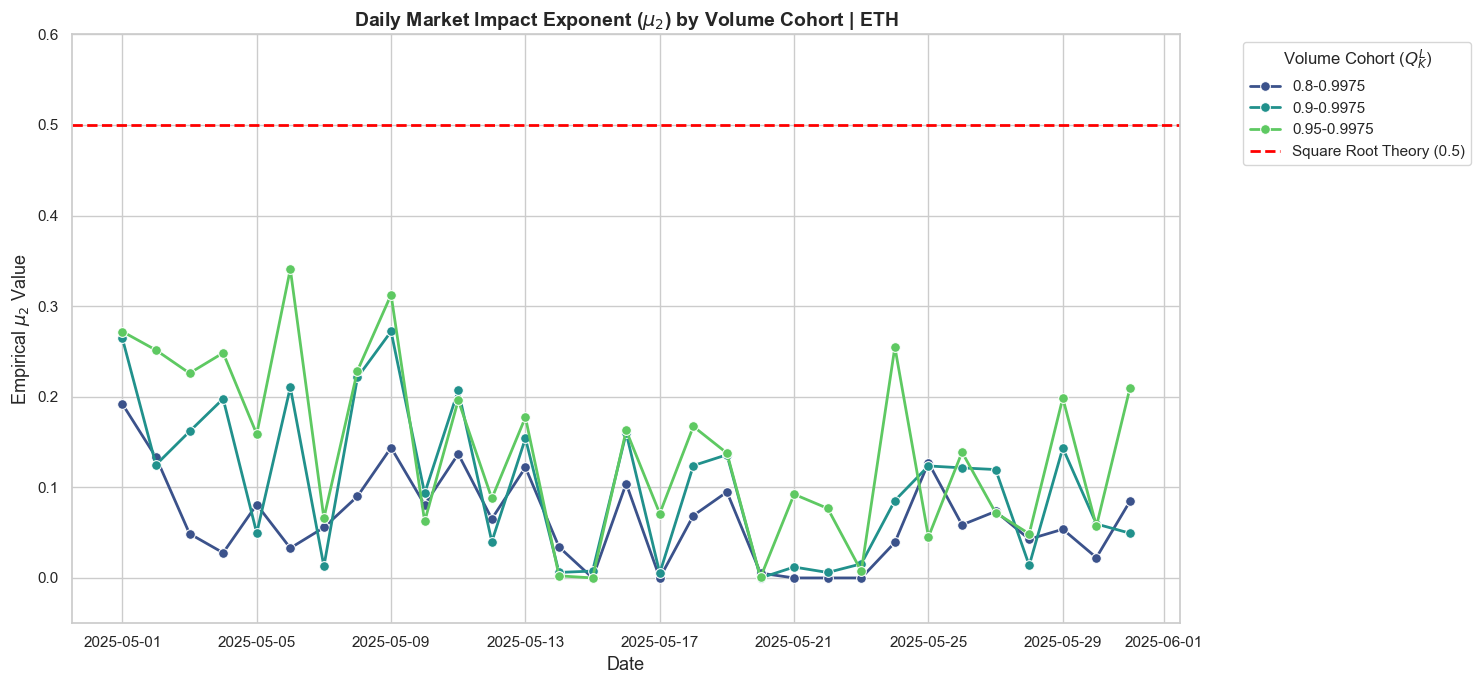

In [19]:
plot_mu2_daily(eth_daily, asset_label="ETH") 

The **empirical exponent remains significantly below the 0.5 Square Root benchmark** across our volume quantiles, ranging from $\mu_2 \approx 0.07$ to $0.14$

In [20]:
def plot_cv_bars(summary_input, asset_label="ETH"):
    # Handle Styler vs DataFrame input
    if hasattr(summary_input, 'data'):
        plot_data = summary_input.data.copy()
    else:
        plot_data = summary_input.copy()
    
    # Set the visual theme
    sns.set_theme(style="whitegrid")

    # Create the figure
    plt.figure(figsize=(10, 7))

    # --- Market Impact Exponent (mu_2) Plot ---
    # Using the new presentation-ready column labels
    plt.bar(plot_data['Volume Quantile'], 
            plot_data['Model 2 (Power Law): Avg μ₂'], 
            yerr=plot_data['Model 2: Std. Dev. μ₂'], 
            capsize=12, 
            color='skyblue', 
            edgecolor='navy', 
            alpha=0.8, 
            label='Empirical Mean (Model 2)')

    # Add the "Theoretical Line" for Bouchard (Square Root Law)
    plt.axhline(0.5, color='red', linestyle='--', linewidth=2.5, 
                label="Bouchard Square Root (0.5)")

    # Formatting
    plt.title(f'Market Impact Exponent ($\mu_2$) by Volume Range | {asset_label}', 
              fontsize=14, fontweight='bold')
    plt.ylabel(r'Mean $\mu_2$ Value (with $\pm$1 Std Dev)', fontsize=12)
    plt.xlabel('Volume Quantile', fontsize=12)

    # Show the gap to 0.5 clearly
    plt.ylim(0, 0.65) 
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

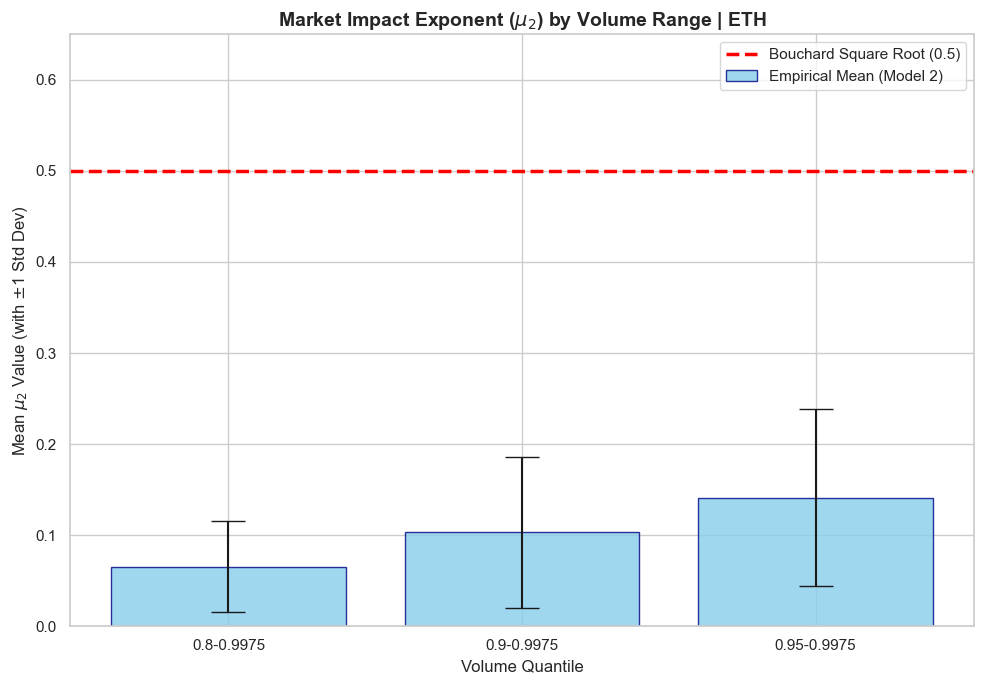

In [21]:
plot_cv_bars(eth_summary.data, asset_label="ETH")

**As trade volume scales** into the extreme tail, **we observe a marginal steepening of the impact curve.**
* However, the empirical exponent ($\mu_2$) remains consistently far below the 0.5 theoretical Square Root benchmark.

In [22]:
def plot_fit_comparison(summary_input, asset_label="ETH"):
    # Handle Styler vs DataFrame input
    if hasattr(summary_input, 'data'):
        plot_data = summary_input.data.copy()
    else:
        plot_data = summary_input.copy()

    # Set the visual theme and figure
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 7))

    x = np.arange(len(plot_data['Volume Quantile']))
    width = 0.35

    # Model Performance Comparison (R-squared)
    # Model 2 (Green = Success), Model 1 (Red = Failure)
    plt.bar(x - width/2, plot_data['Model 2: Avg R²'], width, 
            label='Model 2 (Power Law)', color='forestgreen', alpha=0.8)
    
    plt.bar(x + width/2, plot_data['Model 1 (Square Root): Avg R²'], width, 
            label='Model 1 (Square Root)', color='crimson', alpha=0.8)

    # Formatting
    plt.title(f'Model Goodness-of-Fit Comparison ($R^2$) by Volume Range | {asset_label}', 
              fontsize=14, fontweight='bold')
    plt.xticks(x, plot_data['Volume Quantile'])
    plt.ylabel('Mean $R^2$ Score', fontsize=12)
    plt.xlabel('Volume Quantile', fontsize=12)

    # Dynamic y-axis: Accommodates negative Model 1 scores and adds breathing room for Model 2
    min_r2 = plot_data['Model 1 (Square Root): Avg R²'].min()
    max_r2 = plot_data['Model 2: Avg R²'].max()
    
    # Adds a 0.4 buffer above the highest R^2 value to prevent scraping
    plt.ylim(min_r2 - 2, max_r2 + 0.4) 

    plt.axhline(0, color='black', linewidth=1.5, linestyle='-') # The "Baseline"

    # Add text labels for clarity
    for i, v in enumerate(plot_data['Model 2: Avg R²']):
        plt.text(i - width/2, v + 0.02, f"{v:.2f}", 
                 color='forestgreen', ha='center', fontweight='bold', fontsize=11)

    for i, v in enumerate(plot_data['Model 1 (Square Root): Avg R²']):
        # Offset text slightly differently for negative bars
        plt.text(i + width/2, v - 0.5, f"{v:.2f}", 
                 color='crimson', ha='center', fontweight='bold', fontsize=11)

    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.show()

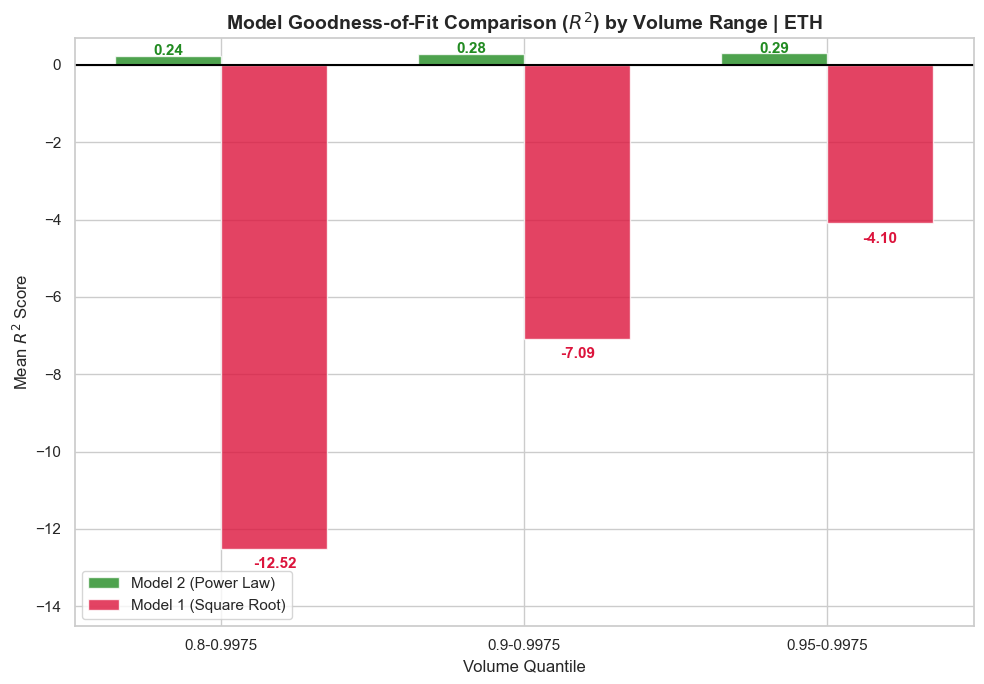

In [23]:
plot_fit_comparison(eth_summary, asset_label="ETH")

**Model 1's fit improves at extreme volumes** as the impact curve steepens toward the 0.5 theoretical benchmark. 
* However, the **consistently negative $R^2$ confirms a fundamental structural mismatch.**

In [24]:
# Function performs a day-by-day analysis for every exchange in the dataset to 
# compare venue-specific liquidity and parameter stability.
def run_exchange_cross(aggregated_df, K_val=0.80, L_val=0.9975, n_buckets=15):

    if 'date' not in aggregated_df.columns:
        aggregated_df['date'] = aggregated_df['ts'].dt.date
        
    full_exchange_results = []
    unique_exchanges = aggregated_df['Exchange'].unique()

    for exchange in unique_exchanges:
        exch_df = aggregated_df[aggregated_df['Exchange'] == exchange]
        
        for day in exch_df['date'].unique():
            day_exch_df = exch_df[exch_df['date'] == day]
            
            # Create buckets
            cohort_data = create_cohort_buckets(day_exch_df, K=K_val, L=L_val, num_buckets=n_buckets)
            
            if cohort_data is None or len(cohort_data) < 5:
                continue
                
            X_data = cohort_data['V_n_mean'].values
            Y_data = cohort_data['r_n_mean'].values
            valid = (X_data > 0) & ~np.isnan(Y_data)
            X_data, Y_data = X_data[valid], Y_data[valid]
            
            if len(X_data) < 5: continue
            
            # --- Fit Model 1 (Square Root) ---
            try:
                popt_1, _ = curve_fit(model_1, X_data, Y_data, bounds=([0], [np.inf]))
                mu_0_est = popt_1[0]
            except:
                mu_0_est = np.nan
                
            # --- Fit Model 2 (Power Law) ---
            try:
                popt_2, _ = curve_fit(model_2, X_data, Y_data, p0=[1e-5, 0.5], 
                                      bounds=([0, 0], [np.inf, 1.0]), maxfev=5000)
                mu_1_est, mu_2_est = popt_2
            except:
                mu_1_est, mu_2_est = np.nan, np.nan
                
            full_exchange_results.append({
                'Exchange': exchange,
                'Date': day,
                'M1_mu0': mu_0_est,
                'M2_mu1': mu_1_est,
                'M2_mu2': mu_2_est
            })

    # Create DataFrame
    exch_full_df = pd.DataFrame(full_exchange_results)

    # Aggregate results
    summary_exch = exch_full_df.groupby('Exchange').agg(
        Avg_M1_mu0=('M1_mu0', 'mean'),
        Avg_M2_mu1=('M2_mu1', 'mean'),
        Avg_M2_mu2=('M2_mu2', 'mean'),
        Std_M2_mu2=('M2_mu2', 'std'),
        Days_Count=('Date', 'count')
    ).reset_index()

    # Apply styling
    styled_summary = summary_exch.style.format({
        'Avg_M1_mu0': '{:.2e}',
        'Avg_M2_mu1': '{:.2e}',
        'Avg_M2_mu2': '{:.4f}',
        'Std_M2_mu2': '{:.4f}'
    }).set_caption(f"<b>Per-Exchange Parameters: Top 20% Cohort</b>")

    return styled_summary

In [25]:
def plot_venue_comparison(summary_input, asset_label="ETH"):
    # Handle Styler vs DataFrame
    if hasattr(summary_input, 'data'):
        plot_data = summary_input.data.copy()
    else:
        plot_data = summary_input.copy()
        
    # Sort by the exponent for a clean visual progression
    plot_data = plot_data.sort_values('Avg_M2_mu2')

    # Set the visual theme and figure
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Create the Bar Plot
    # We use the standard deviation to show venue stability
    plt.bar(
        plot_data['Exchange'], 
        plot_data['Avg_M2_mu2'], 
        yerr=plot_data['Std_M2_mu2'], 
        capsize=10, 
        color='teal', 
        edgecolor='black', 
        alpha=0.7, 
        label='Empirical Mean ($\mu_2$)'
    )

    # Add Bouchard Reference Line
    plt.axhline(0.5, color='red', linestyle='--', linewidth=2.5, 
                label="Bouchard Square Root (0.5)")

    # ormatting
    plt.title(f'{asset_label} Power Law Exponent ($\mu_2$) by Exchange', 
              fontsize=14, fontweight='bold')
    plt.ylabel(r'Mean $\mu_2$ (with $\pm$1 Std Dev)', fontsize=12)
    plt.xlabel('Exchange', fontsize=12)

    plt.ylim(0, 0.9) 
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

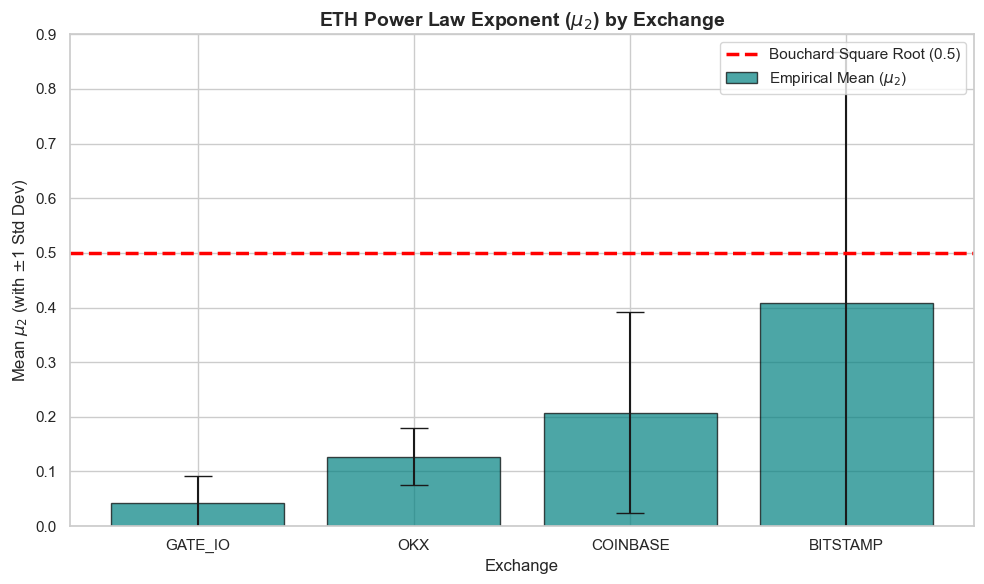

In [26]:
exchanges_eth = run_exchange_cross(eth_aggregated, K_val=0.80, L_val=0.9975, n_buckets=15)
plot_venue_comparison(exchanges_eth) 

In [27]:
exchanges_eth

,Exchange,Avg_M1_mu0,Avg_M2_mu1,Avg_M2_mu2,Std_M2_mu2,Days_Count
0,BITSTAMP,5.94e-04,6.69e-04,0.4085,0.4594,29
1,COINBASE,1.04e-04,1.24e-04,0.2074,0.1841,31
2,GATE_IO,8.90e-05,1.04e-04,0.0420,0.0502,11
3,OKX,3.42e-05,5.74e-05,0.1272,0.0521,31


## 2.4 Exchange-Level Microstructure 
Our cross-venue analysis reveals significant structural variance:
* **Gate.io ($\mu_2 = 0.0420$):** The near-zero exponent shows a "dense" order book where even large trades cause almost no price change.
* **Bitstamp ($\mu_2 = 0.4085$):** A major outlier. It has much thinner liquidity, making it the only venue where price response actually starts to look like the 0.5 Square Root Law.

In [28]:
# Function calculates liquidity metrics per exchange 
def run_depth_diagnostics(aggregated_df, asset_label="ETH"):
    # We use a lambda to ensure the 'r_n' / 'qty' calculation remains row-aligned
    diagnostics = aggregated_df.groupby('Exchange').agg(
        Total_Trades=('qty', 'count'),
        Avg_Trade_Size=('qty', 'mean'),
        Median_Trade_Size=('qty', 'median'),
        # Mean absolute return per unit of volume (Slippage intensity)
        Impact_Per_Vol=('r_n', lambda x: (np.abs(x) / aggregated_df.loc[x.index, 'qty']).mean())
    ).reset_index()

    # format and style
    styled_diagnostics = diagnostics.style.format({
        'Total_Trades': '{:,}',
        'Avg_Trade_Size': '{:.2f}',
        'Median_Trade_Size': '{:.2f}',
        'Impact_Per_Vol': '{:.4e}'
    }).set_caption(f"<b>Market Depth Diagnostics ({asset_label}): Identifying Liquidity Outliers</b>")

    return styled_diagnostics

In [29]:
run_depth_diagnostics(eth_aggregated) 

,Exchange,Total_Trades,Avg_Trade_Size,Median_Trade_Size,Impact_Per_Vol
0,BITSTAMP,"13,314",0.28,0.10,2.8278e+01
1,COINBASE,"467,646",0.54,0.24,8.7839e+01
2,GATE_IO,"2,450,133",0.43,0.03,1.8731e-02
3,OKX,"8,233,017",1.04,0.04,1.9897e-01


**Bitstamp’s significantly thinner book (13,314 total trades) causes price impact to scale much closer to the 0.5 Square Root Law** than any other venue in the study.

# Section 3: Solana (SOL) | Cross-Asset Validation 
We extend pur analytical framework to the Solana (SOL-USDT) ecosystem to test the universality of our ETH findings.

In [30]:
sol_raw = pd.read_parquet('SOL-USDT_fewer_trades.parquet', engine = 'fastparquet') # loads data into Pandas DataFrame.

In [31]:
sol_raw['ts'] = pd.to_datetime(sol_raw['ts']) # ensures 'ts' is datetime and sort by date 
sol_raw = sol_raw.sort_values('ts').reset_index(drop=True) # reset index after full sort for clean slicing
sol_raw['Exchange'].unique()

array(['OKX', 'GATE_IO', 'COINBASE', 'BINANCE'], dtype=object)

The Solana dataset spans four exchanges: **Binance, Coinbase, Gate.io, and OKX.**

In [32]:
sol_aggregated = process_data(sol_raw, M_horizon=10) # process data 

In [33]:
sol_results = fit_models(sol_aggregated) # fit models 

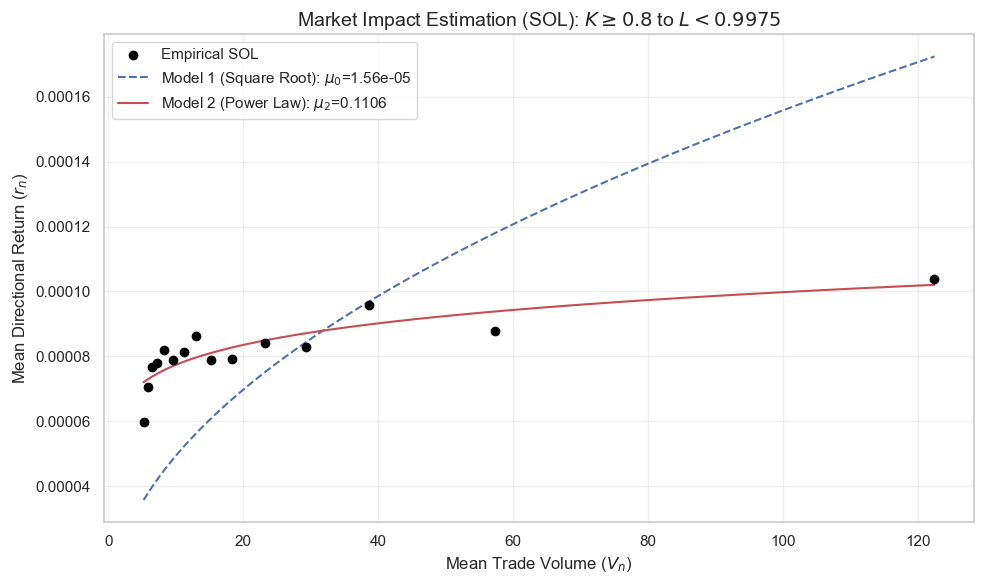

In [34]:
plot_impact_results(sol_results, asset_label = "SOL") 

In [35]:
print(f"SOL Square Root Law (mu_0): {sol_results['mu_0']:.8f}")
print(f"SOL Power Law Exponent (mu_1): {sol_results['mu_1']:.4f}")
print(f"SOL Power Law Exponent (mu_2): {sol_results['mu_2']:.4f}")

SOL Square Root Law (mu_0): 0.00001558
SOL Power Law Exponent (mu_1): 0.0001
SOL Power Law Exponent (mu_2): 0.1106


## 3.1 Market Impact Estimation 
Our Solana (SOL) results **reinforce findings from our previous Ethereum analysis.**
* The SOL Power Law Exponent (0.1106) is far below the 0.50 theoretical benchmark for the Square Root Law.
* The **price impact for SOL "flattens out" as trade size increases.**

In [36]:
get_error_metrics(sol_results, asset_label = "SOL")

Model,MSE,R-squared,Parameters
Model 1 (Square Root),9.7099e-10,-9.3265,μ₀ = 1.56e-05
Model 2 (Power Law),2.5227e-11,0.7317,"μ₁ = 5.99e-05, μ₂ = 0.1106"


## 3.2 Performance Comparison 
Our performance metrics confirm that **the price impact for Solana flattens out significantly faster than classical theory predicts**, with an empirical exponent ($\mu_2 = 0.11$) that is nearly five times smaller than the theoretical benchmark.
* Our Power Law Model explains 73% of the relationship between trade volume and price impact. 
* Conversely, the Square Root Law's $R^2$ of -9.32 means it is worse at predicting the data than a simple average. 
* Model 1's Mean Squared Error (MSE) is nearly 40 times larger than Model 2's. 

In [37]:
# sorts data by day, same quantile ranges as previously 
sol_daily = daily_validation(sol_aggregated, quantile_ranges=None, n_buckets=15) # group into 15 buckets (volume ranges) 

In [38]:
sol_summary = cv_summary(sol_daily, asset_label="SOL")
sol_summary

,Volume Quantile,Avg. Daily Trades,Model 1 (Square Root): Avg R²,Model 2 (Power Law): Avg μ₁,Model 2 (Power Law): Avg μ₂,Model 2: Std. Dev. μ₂,Model 2: Avg R²
0,0.8-0.9975,"55,091",-8.95,7.02e-05,0.0641,0.0760,0.20
1,0.9-0.9975,"27,134",-4.69,7.15e-05,0.0618,0.0841,0.18
2,0.95-0.9975,"13,216",-1.91,5.98e-05,0.1282,0.1441,0.15


## 3.3 Daily Cross-Validation 
Model 2 (Power Law) consistently outperforms, maintaining positive $R^2$ scores across the month.
* In the broader cohorts (Top 20% and Top 10%), the empirical exponent ($mu2$) is tight at between 0.061 to 0.064.

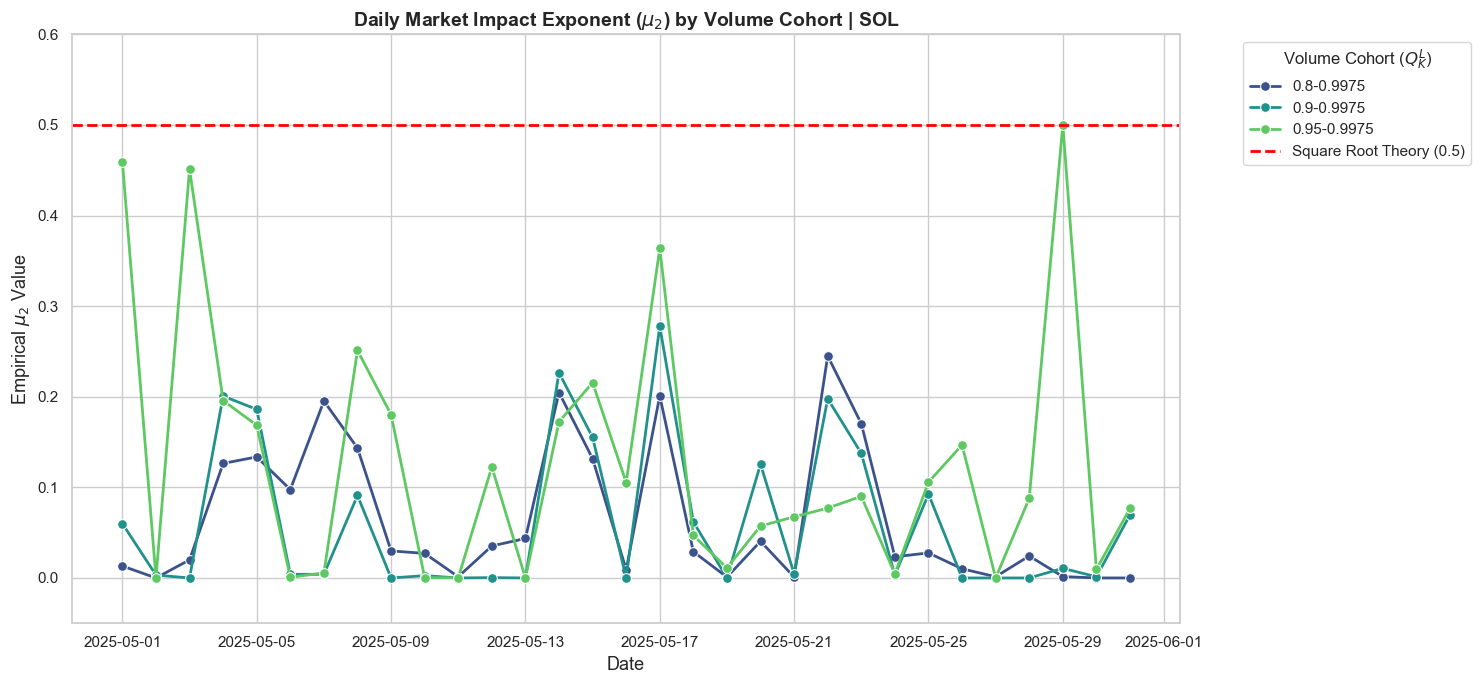

In [39]:
plot_mu2_daily(sol_daily, asset_label="SOL") 

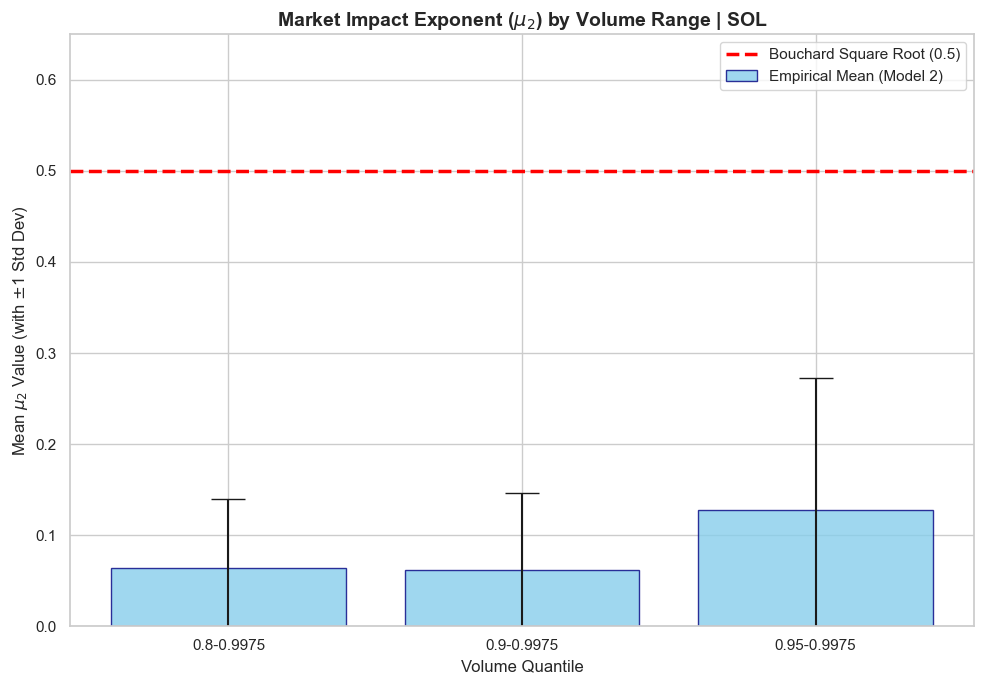

In [40]:
plot_cv_bars(sol_summary.data, asset_label="SOL")

These results validate the ETH baseline: **as trade size scales into the Top 5% cohort, the SOL exponent doubles to 0.1282.**
* While the price response steepens in this high-volume regime, it remains significantly below the 0.5 theoretical benchmark.

## 3.4 Exchange-Level Microstructure

In [41]:
exchanges_sol = run_exchange_cross(sol_aggregated, K_val=0.80, L_val=0.9975, n_buckets=15)
exchanges_sol

,Exchange,Avg_M1_mu0,Avg_M2_mu1,Avg_M2_mu2,Std_M2_mu2,Days_Count
0,BINANCE,1.37e-05,4.26e-05,0.2149,0.0654,8
1,COINBASE,4.44e-05,8.49e-05,0.3837,0.3142,31
2,GATE_IO,3.25e-05,9.18e-05,0.0659,0.0650,31
3,OKX,1.37e-05,5.30e-05,0.1499,0.1469,31


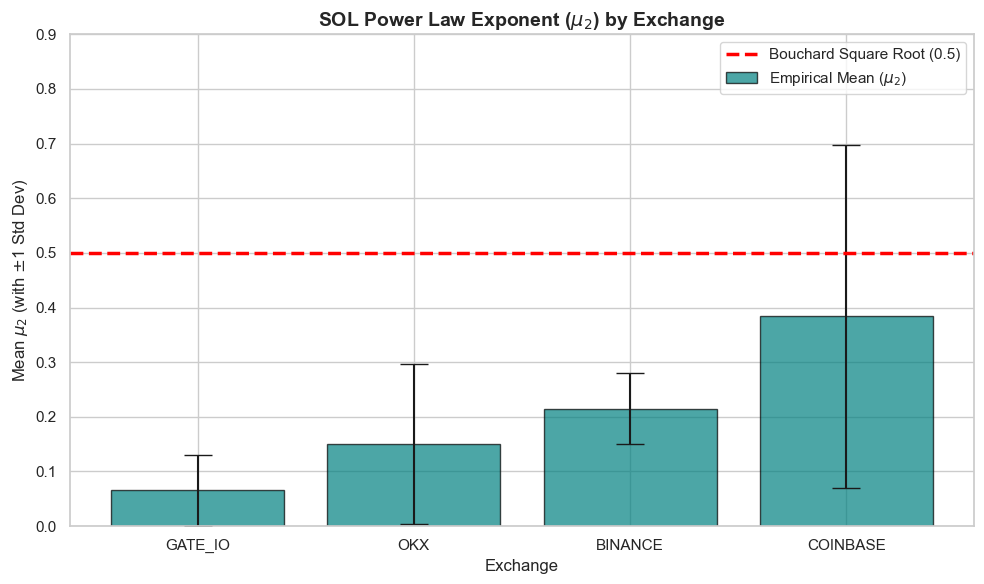

In [42]:
plot_venue_comparison(exchanges_sol, asset_label="SOL") 

In [43]:
run_depth_diagnostics(sol_aggregated) 

,Exchange,Total_Trades,Avg_Trade_Size,Median_Trade_Size,Impact_Per_Vol
0,BINANCE,"2,140,523",11.53,1.11,6.6618e-04
1,COINBASE,"192,035",4.06,1.28,4.1920e-03
2,GATE_IO,"2,504,740",2.54,0.31,3.1232e-03
3,OKX,"3,787,852",7.65,0.67,8.6408e-01


Corroborating the ETH findings, **SOL venues with lower trade frequency exhibit heightened price sensitivity.** 
* Coinbase, the least active venue in our SOL dataset (192,035 trades), serves as the outlier where impact dynamics most closely converge toward the 0.5 theoretical benchmark.

# Section 4: Conclusion 

In [44]:
def generate_master_comparison(eth_res, sol_res, eth_metrics, sol_metrics):
    # Access the raw data from the Styler
    eth_df = eth_metrics.data if hasattr(eth_metrics, 'data') else eth_metrics
    sol_df = sol_metrics.data if hasattr(sol_metrics, 'data') else sol_metrics
    
    def get_r2(df, model_name):
        """Helper to find R-squared even if 'Model' is a column and not the index."""
        # Check if the model name is in the index
        if model_name in df.index:
            return df.loc[model_name, 'R-squared']
        
        # If not, check if there is a 'Model' column
        col_name = 'Model' if 'Model' in df.columns else df.columns[0]
        val = df.loc[df[col_name].str.contains(model_name, na=False, case=False), 'R-squared']
        
        return val.iloc[0] if not val.empty else 0.0

    # Extract R-squared values 
    eth_r2_m1 = get_r2(eth_df, 'Square Root')
    eth_r2_m2 = get_r2(eth_df, 'Power Law')
    
    sol_r2_m1 = get_r2(sol_df, 'Square Root')
    sol_r2_m2 = get_r2(sol_df, 'Power Law')

    # Build the dataset
    data = {
        "Metric": [
            "Model 2 Exponent (μ₂)", 
            "Model 2 Goodness-of-Fit (R²)", 
            "Model 1 Goodness-of-Fit (R²)",
            "Model 1 Coefficient (μ₀)",
            "Model 2 Scaling (μ₁)"
        ],
        "Ethereum (ETH)": [eth_res['mu_2'], eth_r2_m2, eth_r2_m1, eth_res['mu_0'], eth_res['mu_1']],
        "Solana (SOL)": [sol_res['mu_2'], sol_r2_m2, sol_r2_m1, sol_res['mu_0'], sol_res['mu_1']]
    }

    df = pd.DataFrame(data)
    
    # Dynamic observations
    multiplier = sol_res['mu_2'] / eth_res['mu_2']
    df["Observation"] = [
        f"SOL is {multiplier:.1f}x more sensitive to volume",
        "Significantly cleaner fit for SOL data",
        "Classical theory rejected for both assets",
        "Baseline square-root scaling coefficient",
        "Baseline power-law scaling coefficient"
    ]

    # Styling Logic
    def style_master_table(row):
        styles = [''] * len(row)
        styles[0] = 'font-weight: bold; color: #2d3436;' # Bold Metric labels
        
        if "R²" in row['Metric']:
            for i in range(1, 3):
                val = row.iloc[i]
                if val < 0:
                    styles[i] = 'background-color: #ffcccc; color: #d63031; font-weight: bold'
                else:
                    styles[i] = 'background-color: #c8e6c9; color: #2e7d32; font-weight: bold'
        else:
            for i in range(1, 3):
                styles[i] = 'color: black'
        return styles

    return df.style.format({
        "Ethereum (ETH)": "{:.4g}",
        "Solana (SOL)": "{:.4g}"
    }).apply(style_master_table, axis=1
    ).set_caption("<b>Final Comparative Analysis — ETH vs. SOL</b>"
    ).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f8f9fa'), ('font-weight', 'bold'), ('border', '1px solid #dfe6e9')]},
        {'selector': 'td', 'props': [('border', '1px solid #dfe6e9'), ('padding', '10px')]}
    ]).hide(axis='index')

In [45]:
# display results 
eth_metrics_df = get_error_metrics(eth_results)
sol_metrics_df = get_error_metrics(sol_results)
master_table = generate_master_comparison(eth_results, sol_results, eth_metrics_df, sol_metrics_df)
master_table

Metric,Ethereum (ETH),Solana (SOL),Observation
Model 2 Exponent (μ₂),0.03244,0.1106,SOL is 3.4x more sensitive to volume
Model 2 Goodness-of-Fit (R²),0.1825,0.7317,Significantly cleaner fit for SOL data
Model 1 Goodness-of-Fit (R²),-42.84,-9.327,Classical theory rejected for both assets
Model 1 Coefficient (μ₀),4.057e-05,1.558e-05,Baseline square-root scaling coefficient
Model 2 Scaling (μ₁),7.286e-05,5.994e-05,Baseline power-law scaling coefficient


## 4.1 Final Comparative Analysis 
Empirical evidence from both Ethereum and Solana datasets confirms a structural departure from the Square Root Law ($\mu_2 = 0.5$)

While both assets exhibit extreme concavity, their liquidity profiles differ significantly: 
* Solana demonstrates a substantially more stable and cleaner statistical fit ($R^2 = 0.73$)
  is approximately 3.4 times more sensitive to trade volume than Ethereum.
* The near-zero exponent for Ethereum ($0.0324$) suggests a level of top-of-book depth that allows it to absorb institutional sweeps with far less price friction than Solana.